In [1]:
import pandas as pd
import numpy as np
import pdfplumber
import pytesseract
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
from PIL import Image
import re
import os
import platform

In [2]:
pd.read_csv('data\list_company.csv')

,company_name_invoice,company_name_registery,ID_TVA,parent_company
0,BRILL_SA,société_du_parking_brill,LU22991326,0
1,Parking_Brill_SA,société_du_parking_brill,LU22991326,NaN
2,Parking_Brill,société_du_parking_brill,LU22991326,NaN
3,SPBS_SA,société_du_parking_brill,LU22991326,NaN
4,parking d'esch,societe du parking d'Esch-sur-Alzette,LU20558988,0
5,SPESA,societe du parking d'Esch-sur-Alzette,LU20558988,0
6,parking_hotel_de_ville_esch_alzette,societe du parking d'Esch-sur-Alzette,LU20558988,0
7,esch_hotel_de_ville,societe du parking d'Esch-sur-Alzette,LU20558988,0
8,parking_monterey,SPAM,LU16825646,0
9,MONTEREY_S.A.,SPAM,LU16825646,0


In [5]:
platform.system()

'Windows'

In [6]:
from dotenv import load_dotenv
load_dotenv(dotenv_path='./src/.env')

True

In [7]:
os.getenv("TESSERACT_PATH_WIN")

'C:/Program Files/Tesseract-OCR/tesseract.exe'

In [8]:
os.getenv("TESSERACT_PATH_WIN", "tesseract")

'C:/Program Files/Tesseract-OCR/tesseract.exe'

In [2]:
from dotenv import load_dotenv

In [10]:
import platform

platform.system()

'Windows'

In [11]:
list_company = ['brinks','avocat a la cour','sdworx','muller & wegener','mettler','marc decker','3c payment',
                'vigicore','ibgraf','rentokil initial','foyer','nespresso','scheidt & bachman','uncos']

In [2]:
#chemin de pytesseract.exe
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [3]:
dk = pd.read_csv('data\list_company.csv')
dk.head()

,company_name_invoice,company_name_registery,ID_TVA,parent_company
0,BRILL_SA,société_du_parking_brill,LU22991326,0
1,Parking_Brill_SA,société_du_parking_brill,LU22991326,0
2,Parking_Brill,société_du_parking_brill,LU22991326,0
3,SPBS_SA,société_du_parking_brill,LU22991326,0
4,parking d'esch,societe du parking d'Esch-sur-Alzette,LU20558988,0


In [4]:
company_name = ('SPG', 'BOUILLON')

In [5]:
dg = pd.read_csv('./data\supplier_copy.csv')
dg.head()

,entreprise,ID_TVA
0,agimex,LU30148542
1,atelier_de_reliure,LU32492171
2,BMW,LU21427047
3,3c_payment,LU28264772
4,LS_avocat_a_la_cour,LU23014984


In [35]:
dg = pd.read_csv('./data\supplier_copy.csv')
dg = dg.drop(['Unnamed: 0.1','Unnamed: 0'],axis = 1)
dg.sort_values(by="entreprise").to_csv('data\supplier_copy.csv',index=False)

In [19]:
dg.drop_duplicates().shape

(24, 2)

In [28]:
dg.sort_values(by="entreprise").to_csv('data\supplier_copy.csv')

In [9]:
directory_company_match = dk.loc[dk['company_name_invoice'] == company_name[1]].values

In [11]:
directory_company_match[0]

array(['BOUILLON', 'BOUILLON', 'LU10403280', 'SPG'], dtype=object)

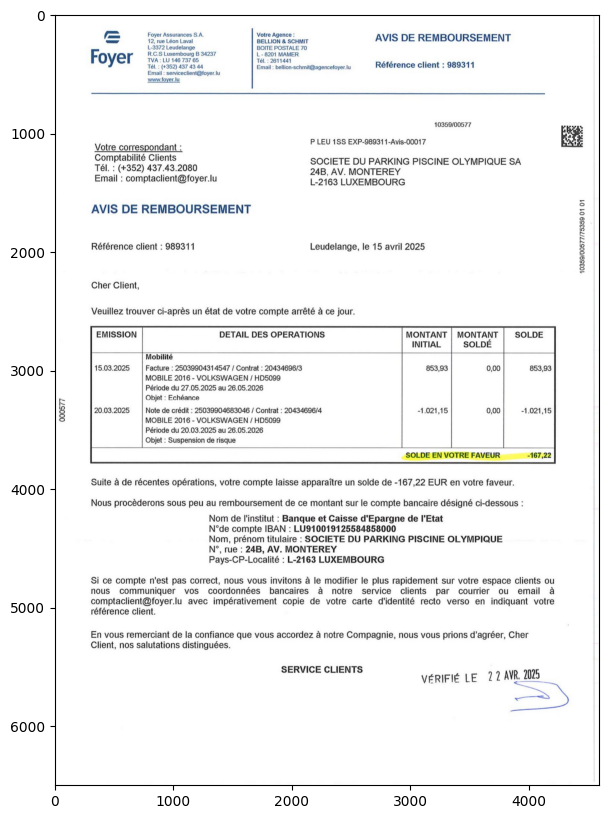

In [159]:

#conversion du chaque page du pdf en image
image_train = convert_from_path(r"data\output\SPPO\new_supplier\facture20250709_173335.pdf")
plt.figure(figsize=(10,10))
plt.imshow(image_train[0])
plt.show()

In [160]:
text_1 = pytesseract.image_to_string(image_train[0]).replace(" ","").strip()
text_1

"000577\n\nooFoyerAssurancesS.A.\n=12,rueLéonLaval\n\nL-3372Leudelange\n\nieR.C.SLuxembourgB34237\noyerTVA:LU14673765\n\nTél.:(+352)4374344\n\nEmail:serviceclient@foyer.lu\n\nwww.foyer.lu\n\nVotrecorrespondant:\nComptabilitéClients\n\nTél.:(+352)437.43.2080\nEmail:comptaclient@foyer.lu\n\nAVISDEREMBOURSEMENT\n\nRéférenceclient:989311\n\nCherClient,\n\nVotreAgence:\n\nBELLION&SCHMITAVISDEREMBOURSEMENT\nBOITEPOSTALE70\n\nL-8201MAMER\n\nTél.:2611441a\n\nEmail:bellion-schmit@agencefoyer.luRéférenceclient:989311\n\n10359/00577\n\nPLEU1SSEXP-989311-Avis-00017\n\nSOCIETEDUPARKINGPISCINEOLYMPIQUESA\n\n24B,AV.MONTEREY\nL-2163LUXEMBOURG\n\nLeudelange,le15avril2025\n\nVeuilleztrouverci-aprésunétatdevotrecomptearrétéacejour.\n\nDETAILDESOPERATIONSMONTANT|MONTANTSOLDE\nINITIALSOLDE\n\nMobilité\n\n15.03.2025Facture:25039904314547/Contrat:20434696/3\nMOBILE2016-VOLKSWAGEN/HD5099\nPériodedu27.05.2025au26.05.2026\n\nObjet:Echéance\n\n20.03.2025Notedecrédit:25039904683046/Contrat:20434696/4-1.021,15\nMO

In [161]:
import unicodedata
import re
import rapidfuzz


text_2 = text_1.lower()
#print(text_2)
text_3 = unicodedata.normalize('NFKD',text_2)
# print(text_3)
text_4 = text_3.encode('ASCII','ignore').decode('utf-8')
# print(text_4)

text_5 = text_4.replace("-", " ").replace("_", " ")
# print(text_6)

text_6 = re.sub(r"[^\w\s]", "", text_5)  # supprime ponctuation
text_7 = re.sub(r"\s+", "", text_6)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
text_8 = text_7.strip()

best_match,score_process,_ = rapidfuzz.process.extractOne(text_8,['parkingtheatre'])


score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_8,['worldline'])
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: 34.285714285714285
score_partial_ratio 0.0


In [162]:
print(text_3)

000577

oofoyerassurancess.a.
=12,rueléonlaval

l-3372leudelange

ier.c.sluxembourgb34237
oyertva:lu14673765

tél.:(+352)4374344

email:serviceclient@foyer.lu

www.foyer.lu

votrecorrespondant:
comptabilitéclients

tél.:(+352)437.43.2080
email:comptaclient@foyer.lu

avisderemboursement

référenceclient:989311

cherclient,

votreagence:

bellion&schmitavisderemboursement
boitepostale70

l-8201mamer

tél.:2611441a

email:bellion-schmit@agencefoyer.luréférenceclient:989311

10359/00577

pleu1ssexp-989311-avis-00017

societeduparkingpiscineolympiquesa

24b,av.monterey
l-2163luxembourg

leudelange,le15avril2025

veuilleztrouverci-aprésunétatdevotrecomptearrétéacejour.

detaildesoperationsmontant|montantsolde
initialsolde

mobilité

15.03.2025facture:25039904314547/contrat:20434696/3
mobile2016-volkswagen/hd5099
périodedu27.05.2025au26.05.2026

objet:echéance

20.03.2025notedecrédit:25039904683046/contrat:20434696/4-1.021,15
mobile2016-volkswagen/hds099
périodedu20.03.2025a

In [163]:
def clean_ocr_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text)  # enlève accents
    text = text.encode('ascii', 'ignore').decode('utf-8')  # remove non-ascii
    text = text.replace("-", " ").replace("_", " ")  # standardise séparateurs
    text = re.sub(r"[^\w\s]", "", text)  # supprime ponctuation
    text = re.sub(r"\s+", "", text)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
    return text.strip()

In [164]:
print(text_8)

000577oofoyerassurancessa12rueleonlavall3372leudelangeiercsluxembourgb34237oyertvalu14673765tel3524374344emailserviceclientfoyerluwwwfoyerluvotrecorrespondantcomptabiliteclientstel352437432080emailcomptaclientfoyerluavisderemboursementreferenceclient989311cherclientvotreagencebellionschmitavisderemboursementboitepostale70l8201mamertel2611441aemailbellionschmitagencefoyerlureferenceclient9893111035900577pleu1ssexp989311avis00017societeduparkingpiscineolympiquesa24bavmontereyl2163luxembourgleudelangele15avril2025veuilleztrouverciapresunetatdevotrecomptearreteacejourdetaildesoperationsmontantmontantsoldeinitialsoldemobilite15032025facture25039904314547contrat204346963mobile2016volkswagenhd5099periodedu27052025au26052026objetecheance20032025notedecredit25039904683046contrat204346964102115mobile2016volkswagenhds099periodedu20032025au26052026objetsuspensionderisquesuiteaderecentesoperationsvotrecomptelaisseapparaitreunsoldede16722eurenvotrefaveur102115nousprocederonssouspeuauremboursementdec

In [ ]:
clean_ocr_text('LU22991326')

In [129]:
print(text_8)

lavauxluxembourgsocietearesponsabilitelimitee3ruelaiteschbaachl5324conterntel26501462fax26501463emaillavauxluxlavauxlusitewwwlavauxlusocietearesponsabritelimiteeaucapitalde250000eurosrcsluxembourg6134985ndidentificationtvalu22257070nmatricule20072466757autorisationdetablissementn119578nettoyeurdebatimentsetdemonumentsaitorisationdetablissementn119578atransportdeasrckallasesparrouteavecdesvehiculesdeplusde35tonnesrakingdintervention16ueducommercel4220eschsuralzetteluxembourgdate17032025nfacturela3072503fac01200factureoriginaletravauxrealisesle14032025articledeplacementdedeuxvehiculesvidangeetlavagedeseparateurahydrocarburestransportetvidangeencentredetraitementtraitementdeseauxhydrocarbureestraitementdesboueshydrocarbureescodeclientecheance30042025banquebglbnpparibassepacredittransferooibanlu670030296759700000codebicbglllullbasetva1298101700papillonajoindreavotrereglementoureferencesarappelerafindevitertouslitigesmercinfacturemontant41060191la3072503faco01200151878eurmodepaiementparkolu

In [102]:
clean_ocr_text('snct')

'snct'

In [165]:
text_9 = clean_ocr_text(text_1)

In [ ]:
score_process = rapidfuzz.process.extractOne(text_8,clean_ocr_text('foyer_assurances'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_8,
                                                    clean_ocr_text('foyer'))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('f', 60.0, 0)
score_partial_ratio 100.0


In [141]:
clean_ocr_text('LU22991326') in text_9

True

In [93]:
clean_ocr_text('LU391111700891660000') in text_8

False

In [158]:
score_process = rapidfuzz.process.extractOne(text_9,clean_ocr_text('sudenergie'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_9,
                                                    clean_ocr_text('sudenergie'))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('s', 60.0, 0)
score_partial_ratio 100.0


LU391111700891660000

In [62]:
type(score_partial_ratio)

float

In [ ]:
[parking_du_theatre,parking_theatre,theatre,SPT_SA]

In [ ]:
from rapidfuzz import process


best_match,score,_ = process.extractOne(text_6,['parkingtheatre'])
best_match,score,_ 

('parkingtheatre', 55.714285714285715, 0)

In [ ]:
import unicodedata
import re
import rapidfuzz


text_2 = text_1.lower()
#print(text_2)
text_3 = unicodedata.normalize('NFKD',text_2)
# print(text_3)
text_4 = text_3.encode('ASCII','ignore')
# print(text_4)

text_5 = text_4.decode('utf-8')
# print(text_5)

text_6 = text_5.replace("-", " ").replace("_", " ")
# print(text_6)

best_match,score_process,_ = process.extractOne(text_6,['parkingtheatre'])
best_match,score_process,_ 

score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_6,['parkingtheatre'])
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

In [38]:
from rapidfuzz import process


best_match,score,_ = process.extractOne(text_6,['parkingtheatre'])
best_match,score,_ 

('parkingtheatre', 55.714285714285715, 0)

In [48]:
'sdworx' in text_3

True

In [11]:
text_4 = text_3.encode('ASCII','ignore')
text_4
text_5 = text_4.decode('utf-8')
print(text_5)


ibgroupfacturenibp0032

ibprotectiondate:12-03-2025
ibcars

60rtedeluxembourg
5408bous-luxembourg
tel:+3522666016635
email:info@ib-group.lu

societeduparkingthedatres.a(spt)
24bavenuemonterey

l-2163luxembourg

luxembourg

tva:

offredeprixextincteurs:parkingplacedutheatreluxemboug

devisnd-0052du07-02-2025

extincteurabc6kgpp34a233b31,65]17,00%

deplacementsud30,00}17,00%

tvasoustotalht852,90
remiseglobale3,00%

totalht827,31
totaltva140,64

dated'emission:12-03-202518:41:12

dated'echeance:12-03-2025(areception)
encasderetarddepaiement,applicationd'uneindemniteforfaitairepourfraisdetotalttc967,95
recouvrementde40selonl'articled.441-5ducodeducommerce.

modedepaiement:virement
netapayer967,95

iban:lu451111757536630000bic:ccpllull

verifiele27mars2025eae

ibgroupsarl-s
60rtedeluxembourg-5408bous,luxembourg
ntva:lu35272316-rcs:b281023-matricule:20232451514
capitalde1500

1/1


In [ ]:
text_6 = text_5.replace("-", " ").replace("_", " ")
print(text_6)
text_

ibgroupfacturenibp0032

ibprotectiondate:12 03 2025
ibcars

60rtedeluxembourg
5408bous luxembourg
tel:+3522666016635
email:info@ib group.lu

societeduparkingthedatres.a(spt)
24bavenuemonterey

l 2163luxembourg

luxembourg

tva:

offredeprixextincteurs:parkingplacedutheatreluxemboug

devisnd 0052du07 02 2025

extincteurabc6kgpp34a233b31,65]17,00%

deplacementsud30,00}17,00%

tvasoustotalht852,90
remiseglobale3,00%

totalht827,31
totaltva140,64

dated'emission:12 03 202518:41:12

dated'echeance:12 03 2025(areception)
encasderetarddepaiement,applicationd'uneindemniteforfaitairepourfraisdetotalttc967,95
recouvrementde40selonl'articled.441 5ducodeducommerce.

modedepaiement:virement
netapayer967,95

iban:lu451111757536630000bic:ccpllull

verifiele27mars2025eae

ibgroupsarl s
60rtedeluxembourg 5408bous,luxembourg
ntva:lu35272316 rcs:b281023 matricule:20232451514
capitalde1500

1/1


['i',
 'b',
 'g',
 'r',
 'o',
 'u',
 'p',
 'f',
 'a',
 'c',
 't',
 'u',
 'r',
 'e',
 'n',
 'i',
 'b',
 'p',
 '0',
 '0',
 '3',
 '2',
 '\n',
 '\n',
 'i',
 'b',
 'p',
 'r',
 'o',
 't',
 'e',
 'c',
 't',
 'i',
 'o',
 'n',
 'd',
 'a',
 't',
 'e',
 ':',
 '1',
 '2',
 ' ',
 '0',
 '3',
 ' ',
 '2',
 '0',
 '2',
 '5',
 '\n',
 'i',
 'b',
 'c',
 'a',
 'r',
 's',
 '\n',
 '\n',
 '6',
 '0',
 'r',
 't',
 'e',
 'd',
 'e',
 'l',
 'u',
 'x',
 'e',
 'm',
 'b',
 'o',
 'u',
 'r',
 'g',
 '\n',
 '5',
 '4',
 '0',
 '8',
 'b',
 'o',
 'u',
 's',
 ' ',
 'l',
 'u',
 'x',
 'e',
 'm',
 'b',
 'o',
 'u',
 'r',
 'g',
 '\n',
 't',
 'e',
 'l',
 ':',
 '+',
 '3',
 '5',
 '2',
 '2',
 '6',
 '6',
 '6',
 '0',
 '1',
 '6',
 '6',
 '3',
 '5',
 '\n',
 'e',
 'm',
 'a',
 'i',
 'l',
 ':',
 'i',
 'n',
 'f',
 'o',
 '@',
 'i',
 'b',
 ' ',
 'g',
 'r',
 'o',
 'u',
 'p',
 '.',
 'l',
 'u',
 '\n',
 '\n',
 's',
 'o',
 'c',
 'i',
 'e',
 't',
 'e',
 'd',
 'u',
 'p',
 'a',
 'r',
 'k',
 'i',
 'n',
 'g',
 't',
 'h',
 'e',
 'd',
 'a',
 't',
 'r',
 'e',


In [13]:
from rapidfuzz import fuzz
from rapidfuzz import process

In [14]:
fuzz.ratio('parkingdutheatre','parkingthedatres')

87.5

In [15]:
fuzz.partial_ratio('parkingdutheatre','parkingthedatres')

90.32258064516128

In [ ]:
# text_7 = text_6.replace("-", " ").replace("_", " ")
# text_8 = re.sub(r"[^\w\s]", "", text_7)  
# text_9 = re.sub(r"\s+", "", text_8)

# text_9      

'paymentpartofplanetsocieteduparkingdutheatresa24bavenuemontereyl2163luxembourgluxembourginvoicen349257invoicedate20241130november2024duedate20241230creditdebitcardprocessingfeesbillingaccountn140021yourvattaxidnlu12067277locationlocationnametransprocessedamountinvoicingbasisfeecurrency239008parkingtheatresaacscptotal112705eur107344parkingtheatre10436790204864eurcontracttermstransactionfee01452eurminimummonthlyfee12705eurincludingfreetransactions750transactionfee0088eur217569eurfixcostdescriptionfeecurrencyrental55288eurtotal2total12272857vattotal46386grandtotal39a45pleasealwaysmentionthecustomernumberonpaymentswekindlyaskyoutopaytheamountwithin30daystothebankaccountnumberibanlu480024134879700000atdexiabilbicbilllullforanybillingenquiriespleasecontactbilling1lu3cpaymentcomverifiefe18dec3cpaymentluxembourgsa57rueleonlavall3372lleudelangeluxembourgvatnlu28264772traderegisterb202905'

In [ ]:
# 'sptsa' in text_9

False

In [ ]:
#selection des pages de facture contenant la mention verifiée
import unicodedata


image_facture_keep=[]


for i,image in enumerate(image_train):
    text = pytesseract.image_to_string(image)
    print(text)
    if "verifie le" in text.lower():
        image_facture_keep.append(image)
        for elmt in list_company:
            if elmt in text.lower():
                print(text.lower)
                print('STOPPPPPPPPPPPPPPP')
                elmt = elmt.strip()
                elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
                elmt = elmt.replace(' ','_')
                print(elmt)
                if not os.path.exists(elmt):
                    os.makedirs(elmt)
                    print(f"dossier {elmt} créé")
                else:
                    print(f"dossier {elmt} déjà existant")
                image.convert("RGB").save(os.path.join(elmt,f"facture{i+1}.pdf"))



In [ ]:
list_company_guillaume = pd.read_csv()

In [ ]:
clean_text = text.lower().replace(" ","").replace("-","")

In [ ]:
for i,image in enumerate(image_train):
    text = pytesseract.image_to_string(image)
    print(text)
    if "verifie le" in text.lower():
        image_facture_keep.append(image)
        clean_text = text.lower().replace(" ","").replace("-","")
        for elmt in list_company_guillaume:
            if elmt.lower().replace(" ","") in clean_text:
               elmt = elmt.strip()
               elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
               elmt = elmt.replace(' ','_')
               print(elmt)
               if not os.path.exists(os.path.join('SPG',):

        
        
        
        
        for elmt in list_company:
            if elmt in text.lower():
                print(text.lower)
                print('STOPPPPPPPPPPPPPPP')
                elmt = elmt.strip()
                elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
                elmt = elmt.replace(' ','_')
                print(elmt)
                if not os.path.exists(elmt):
                    os.makedirs(elmt)
                    print(f"dossier {elmt} créé")
                else:
                    print(f"dossier {elmt} déjà existant")
                image.convert("RGB").save(os.path.join(elmt,f"facture{i+1}.pdf"))

In [ ]:
image_facture_keep=[]


for i,image in enumerate(image_train):
    text = reader.readtext(np.array(image))
    detected_text = [elmt[1] for elmt in text]
    print(detected_text)
    
    if "verifie le" in detected_text:
        image_facture_keep.append(image)
        for elmt in list_company:
            if elmt in text.lower():
                print(text.lower)
                print('STOPPPPPPPPPPPPPPP')
                elmt = elmt.strip()
                elmt = re.sub(r'[<>:"/\\|?*]', '', elmt)
                elmt = elmt.replace(' ','_')
                print(elmt)
                if not os.path.exists(elmt):
                    os.makedirs(elmt)
                    print(f"dossier {elmt} créé")
                else:
                    print(f"dossier {elmt} déjà existant")
                image.convert("RGB").save(os.path.join(elmt,f"facture{i+1}.pdf"))

In [ ]:
#on convertit chaque image de facture en un fichier pdf

for i, img in enumerate(image_facture_keep):
    path = os.path.join()
    img.convert("RGB").save(f"facture_{i+1}.pdf")

In [51]:
['brinks','avocat a la cour','sdworx','muller & wegener','mettler','marc decker','3c payment','vigicore','ibgraf','rentokil initial','foyer','nespresso','scheidt & bachman']

['brinks',
 'avocat a la cour',
 'sdworx',
 'muller & wegener',
 'mettler',
 'marc decker',
 '3c payment',
 'vigicore',
 'ibgraf',
 'rentokil initial',
 'foyer',
 'nespresso',
 'scheidt & bachman']

In [16]:
df = pd.read_csv('./data/company.csv',sep=',')
df.head()

,entreprise,ID_TVA
0,brinks,LU10627004
1,sd workx,LU19477139


In [54]:
# config.py
df = pd.read_csv('company.csv',sep=',')
LIST_COMPANY = list(df['entreprise'])
NEW_COMPANY = "new_company"
TESSERACT_PATH = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
INPUT_PDF = "20250523080415005.pdf"
OUTPUT_DIR = "output"

In [55]:
#utils
def check_invoice(text):
    """
    check the invoice's page where "verifie le " is written

    Args:
        text (str): ten invoice's text

    Returns:
        True or False
    """
    return "verifie le" in text.lower()



def check_company(text, company_list=LIST_COMPANY):
    """
    check the company name in the invoice

    return
        company name or None

    """    
    for company_name in company_list:
        if company_name.lower().replace(" ","") in text.lower().replace(" ",""):
            return company_name
    
    return None



def normalise_company_name(text):
    """
    preprocess the companies name directory

    Args:
        text (str): company's name

    Returns:
        text
    """
    
    text = text.strip()
    text = re.sub(r'[<>:"/\\|?*]','',text)
    text = text.replace(' ','_')
    return text


def convert_pdf_to_PIL(INPUT_PDF):
    image = convert_from_path(INPUT_PDF)
    return image


def make_directory_company(directory,output_dir=OUTPUT_DIR):
    """
    Create a directory if it doesn't exist.

    Args:
        directory (str): The path of the directory to be created.

    Returns:
        None
    """
    path = os.path.join(output_dir,directory)
    print(path)
    
    if not (os.path.exists(path)):
        os.makedirs(path)
        print(f"dossier {directory} créé")
        return path
    else:
        print(f"dossier {directory} déjà existant")
        return path
    



In [ ]:
def convert_invoice_pdf(input_pdf=INPUT_PDF,new_company=NEW_COMPANY):
    """
    convert the Image PIL into pdf files

    Args:
        image : invoice image 
    """
    
    images = convert_pdf_to_PIL(input_pdf)
    
    for i,image in enumerate(images):
        text = pytesseract.image_to_string(image)
        
        
        if check_invoice(text):
            company_name = check_company(text)

            if company_name:
                norm_name = normalise_company_name(company_name)

            else:
                norm_name = normalise_company_name(new_company)

            dir_path = make_directory_company(directory=norm_name)
            image.convert('RGB').save(os.path.join(dir_path,f"facture{i+1}.pdf"))
            print(f"facture{i+1}.pdf enregistré dans {dir_path}")

        
        else:
            print("Factures non validées")
                    
                
        
        

In [57]:
convert_invoice_pdf()

output\brinks
dossier brinks créé
facture1.pdf enregistré dans output\brinks
output\olinn
dossier olinn créé
facture2.pdf enregistré dans output\olinn
output\reiserbann
dossier reiserbann créé
facture3.pdf enregistré dans output\reiserbann
output\Taxes_communales
dossier Taxes_communales créé
facture4.pdf enregistré dans output\Taxes_communales
Factures non validées
output\climalux
dossier climalux créé
facture6.pdf enregistré dans output\climalux
Factures non validées
output\climalux
dossier climalux déjà existant
facture8.pdf enregistré dans output\climalux
Factures non validées
output\uncos
dossier uncos créé
facture10.pdf enregistré dans output\uncos
Factures non validées
Factures non validées
Factures non validées
Factures non validées
output\3C_Payment
dossier 3C_Payment créé
facture15.pdf enregistré dans output\3C_Payment


In [ ]:
import shutil, os

shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

In [2]:
import os

In [7]:
INPUT_PDF_FOLDER = "data/input"

In [8]:
os.listdir(INPUT_PDF_FOLDER)

['20250523080415005.pdf', '20250523113438226.pdf', '20250523115647130.pdf']

In [11]:
dg = pd.read_csv('data/company.csv')
dg

,entreprise,ID TVA
0,brinks,LU10627004
1,sd workx,LU19477139
2,uncos,LU23553238
3,3C Payment,LU28264772
4,SNCT,LU251806425
5,olinn,LU10467309
6,reiserbann,LU32255115
7,Taxes communales,LU10286570
8,climalux,LU19097974
9,Bilia,LU21427047


In [12]:
from datetime import datetime

In [ ]:
datetime.now().strftime("%Y%m%d_%H%M%S")

datetime.datetime(2025, 6, 6, 22, 49, 43, 346573)

In [3]:
import os

In [4]:
print(__file__)

NameError: name '__file__' is not defined